In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

###classification

In [ ]:
fmnist_data=keras.datasets.fashion_mnist

###load_data

In [ ]:
(x_train,y_train),(x_test,y_test)=fmnist_data.load_data()

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
y_test.shape

(10000,)

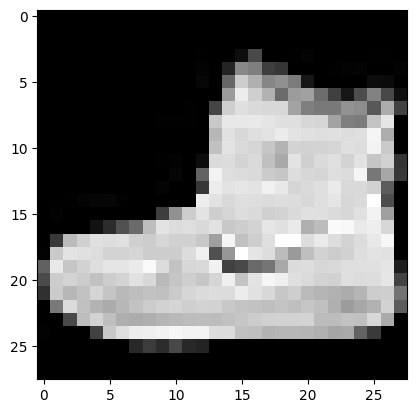

In [ ]:
plt.imshow(x_train[0],cmap='gray')

####normalizer


In [ ]:
x_train,x_test=x_train/255,x_test/255

In [ ]:
x_train.shape

(60000, 28, 28)

###model

In [ ]:
# model = keras.models.Sequential([
#     keras.layers.Flatten(input_shape=[28,28]),
#     keras.layers.Dense(250, activation='relu'),
#     keras.layers.Dense(125, activation='relu'),
#     keras.layers.Dense(75, activation='relu'),
#     keras.layers.Dense(10, activation='softmax')
# ])
# Dropout به طور تصادفی برخی نورون‌ها را در طول آموزش غیرفعال می‌کند تا مدل بیش از حد به داده‌های آموزشی وابسته نشود.
model =keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(128, activation='relu'),
    Dropout(0.3),
    keras.layers.Dense(64,activation='relu'),
    Dropout(0.3),
    # keras.layers.Dense(32,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers


[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>]

###get_weights

In [ ]:
weight,bias=model.layers[1].get_weights()

In [ ]:
weight

array([[-0.02765657, -0.03087607,  0.01361176, ..., -0.0001952 ,
        -0.06502964,  0.02886516],
       [ 0.04043458,  0.03046896,  0.00388702, ...,  0.01465783,
         0.03723806, -0.02304077],
       [ 0.01746349, -0.07432842,  0.03374141, ...,  0.02054339,
         0.06126126,  0.02084394],
       ...,
       [ 0.06834998, -0.07009468,  0.03667954, ..., -0.05894107,
        -0.01427157,  0.01793442],
       [ 0.01055717, -0.03256752,  0.00452663, ...,  0.07418036,
        -0.04004295, -0.07416888],
       [-0.0716612 , -0.06253538,  0.07002946, ...,  0.05011228,
        -0.00478043,  0.07473097]], dtype=float32)

In [ ]:
bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

###compile

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


###fit

In [ ]:
# از callback برای توقف آموزش وقتی validation loss دیگر بهبود نمی‌یابد
# patience=5 یعنی اگر ۵ epoch متوالی val_loss بهتر نشد، آموزش متوقف شود.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(x_train,y_train,epochs=30,validation_split=0.1)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6958 - loss: 0.8523 - val_accuracy: 0.8428 - val_loss: 0.4161
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8282 - loss: 0.4775 - val_accuracy: 0.8533 - val_loss: 0.3944
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8434 - loss: 0.4388 - val_accuracy: 0.8635 - val_loss: 0.3742
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8512 - loss: 0.4072 - val_accuracy: 0.8690 - val_loss: 0.3627
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8586 - loss: 0.3946 - val_accuracy: 0.8682 - val_loss: 0.3529
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8613 - loss: 0.3831 - val_accuracy: 0.8783 - val_loss: 0.3435
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8690 - loss: 0.3620 - val_accuracy: 0.8783 - val_loss: 0.3345
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8684 - loss: 0.3588 -

In [ ]:
history.history

{'accuracy': [0.6032962799072266,
  0.7461851835250854,
  0.7797407507896423,
  0.7997778058052063,
  0.8148518800735474,
  0.8240925669670105,
  0.8310555815696716,
  0.8355370163917542,
  0.8411481380462646,
  0.8459444642066956,
  0.8492777943611145,
  0.8526111245155334,
  0.853592574596405,
  0.8560000061988831,
  0.8600000143051147,
  0.8608888983726501,
  0.86514812707901,
  0.8645185232162476,
  0.8652222156524658,
  0.866777777671814,
  0.8698703646659851,
  0.8703888654708862,
  0.8724444508552551,
  0.8740741014480591,
  0.8722777962684631,
  0.8727407455444336,
  0.8757222294807434,
  0.876703679561615,
  0.8771296143531799,
  0.876629650592804],
 'loss': [1.0609688758850098,
  0.6818409562110901,
  0.604168176651001,
  0.5574218034744263,
  0.5205246210098267,
  0.49545806646347046,
  0.47577452659606934,
  0.45950108766555786,
  0.44793540239334106,
  0.4344773590564728,
  0.4256381690502167,
  0.4148455560207367,
  0.4107952117919922,
  0.40042486786842346,
  0.393376260

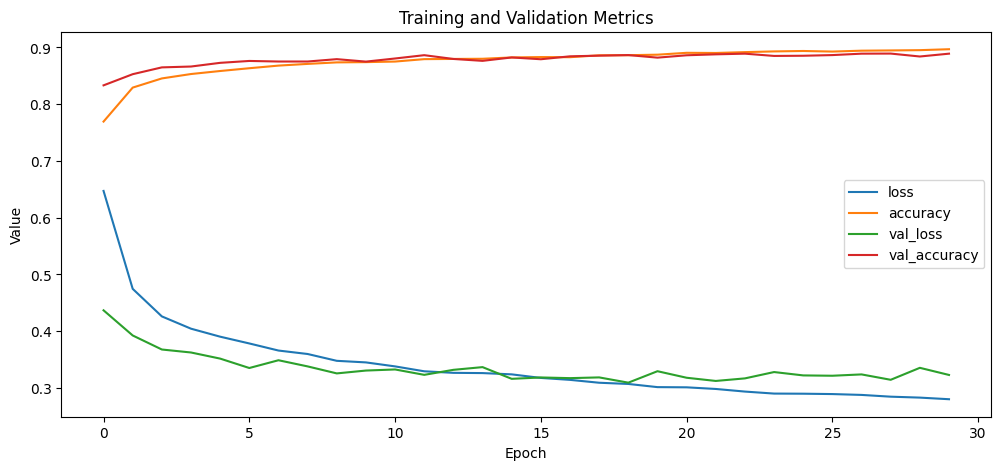

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['accuracy'], label='accuracy')
ax.plot(history.history['val_loss'], label='val_loss')
ax.plot(history.history['val_accuracy'], label='val_accuracy')

ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_title('Training and Validation Metrics')
ax.legend()
plt.show()

###play with data test

In [1]:
model.evaluate(x_test,y_test,verbose=0)

NameError: name 'model' is not defined

In [ ]:
x3=x_test[1:3,:,:]
x_test.shape

NameError: name 'x_test' is not defined

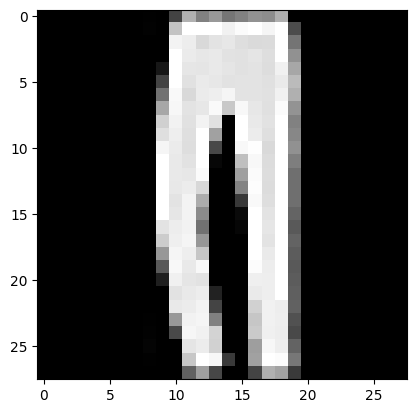

In [ ]:
plt.imshow(x3[0],cmap='gray')

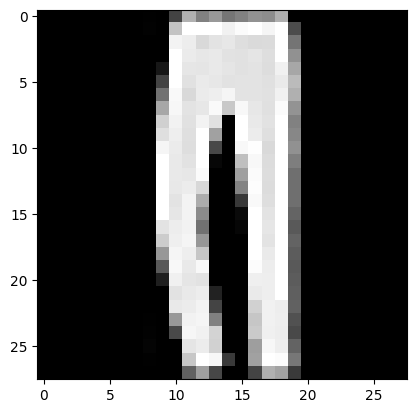

In [ ]:
plt.imshow(x3[1],cmap='gray')


In [ ]:
model.predict(x3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


array([[2.7504032e-06, 3.0639471e-16, 9.9931288e-01, 3.5678169e-13,
        4.3928061e-04, 3.2927594e-30, 2.4517783e-04, 2.0738838e-37,
        5.0415221e-14, 8.0950205e-33],
       [7.8607842e-14, 1.0000000e+00, 1.0130982e-20, 7.4447369e-15,
        2.8505134e-18, 1.1520047e-35, 4.3670535e-19, 1.1840972e-42,
        8.1027278e-16, 1.3528135e-41]], dtype=float32)

In [ ]:
model.predict(x3).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


(2, 10)

In [ ]:
model.predict(x3).round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[0.   , 0.   , 0.999, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ]], dtype=float32)